In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [18]:
# Load all hives from unified CSV and filter by hive name
all = pd.read_csv('../../data/12062026all_boxes.csv')
df2 = all[(all['Hive name'] == 2)]
df4 = all[(all['Hive name'] == 4)]
df13 = all[(all['Hive name'] == 13)]   
df1 = all[(all['Hive name'] == 1)]
df3 = all[(all['Hive name'] == 3)]

In [20]:
dfs = [df2, df4, df13, df1, df3]

#Convert the 'Time' column to datetime and sort the dataframes by time
for i, df in enumerate(dfs):
    dfs[i]['Time'] = pd.to_datetime(df['Time'])
    dfs[i] = df.sort_values('Time').reset_index(drop=True)

# Extract year from 'Time' for easier filtering
for i, df in enumerate(dfs):
    dfs[i]['year'] = dfs[i]['Time'].dt.year

C:\Users\migue\AppData\Local\Temp\ipykernel_26540\2238277768.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs[i]['Time'] = pd.to_datetime(df['Time'])
C:\Users\migue\AppData\Local\Temp\ipykernel_26540\2238277768.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs[i]['Time'] = pd.to_datetime(df['Time'])
C:\Users\migue\AppData\Local\Temp\ipykernel_26540\2238277768.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs[i]['Time'] = pd.to_datetime(df['Time'])
C:\Us

In [21]:
# Check for missing values in each DataFrame
for i, df in enumerate(dfs):
    nulls = dfs[i].isnull().sum()
    pct = (nulls / len(dfs[i]) * 100).round(2)
    print(f"DataFrame {i+1} - Missing Values:")


DataFrame 1 - Missing Values:
DataFrame 2 - Missing Values:
DataFrame 3 - Missing Values:
DataFrame 4 - Missing Values:
DataFrame 5 - Missing Values:


In [22]:
# Create dictionaries to access data by year
box2_years = {y: d for y, d in dfs[0].groupby('year')}
box4_years = {y: d for y, d in dfs[1].groupby('year')}
box13_years = {y: d for y, d in dfs[2].groupby('year')}
box1_years = {y: d for y, d in dfs[3].groupby('year')}
box3_years = {y: d for y, d in dfs[4].groupby('year')}

print("Available years for Box2:", list(box2_years.keys()))
print("Available years for Box4:", list(box4_years.keys()))
print("Available years for Box13:", list(box13_years.keys()))
# Access data for specific years
box2_2024 = box2_years[2024]
box2_2025 = box2_years[2025]
box2_2026 = box2_years[2026]

box4_2024 = box4_years[2024]
box4_2025 = box4_years[2025]
box4_2026 = box4_years[2026]

box13_2024 = box13_years[2024]
box13_2025 = box13_years[2025]
box13_2026 = box13_years[2026]

box1_2024 = box1_years[2024]
box1_2025 = box1_years[2025]
box1_2026 = box1_years[2026]

box3_2024 = box3_years[2024]
box3_2025 = box3_years[2025]
box3_2026 = box3_years[2026]

Available years for Box2: [2023, 2024, 2025, 2026]
Available years for Box4: [2023, 2024, 2025, 2026]
Available years for Box13: [2023, 2024, 2025, 2026]


In [23]:
def clean_weight(df, max_step=3):

    df = df.copy()
    df = df.sort_values('Time')

    diff = df['Weight'].diff().abs()

    df.loc[diff > max_step, 'Weight'] = None

    df['Weight'] = df['Weight'].interpolate()

    return df

def extract_heart(df):

    return df[df['Temperature heart'].notna()][[
        'Time',
        'Temperature heart',
        'Humidity heart',
        'Frequency',
        'Volume',
        'Weight'
    ]].reset_index(drop=True)

import matplotlib.pyplot as plt

def plot_basic(df, title):

    fig, axes = plt.subplots(4, 1, figsize=(14,8), sharex=True)

    axes[0].plot(df['Time'], df['Temperature heart'])
    axes[0].set_ylabel("Temp")

    axes[1].plot(df['Time'], df['Humidity heart'])
    axes[1].set_ylabel("Humidity")

    axes[2].plot(df['Time'], df['Weight'])
    axes[2].set_ylabel("Weight")

    axes[3].plot(df['Time'], df['Frequency'])
    axes[3].set_ylabel("Activity")

    plt.suptitle(title)
    plt.show()

In [24]:
def create_features(df):

    df = df.copy()
    df = df.sort_values("Time")

    window = 18  # ~3h

    df["temp_std"] = df["Temperature heart"].rolling(window).std()
    df["humidity_std"] = df["Humidity heart"].rolling(window).std()
    df["activity_std"] = df["Frequency"].rolling(window).std()

    df["temp_diff"] = df["Temperature heart"].diff()
    df["activity_diff"] = df["Frequency"].diff()
    df["weight_diff"] = df["Weight"].diff()

    df["temp_std_diff"] = df["temp_std"].diff()
    df["activity_std_diff"] = df["activity_std"].diff()

    df["temp_range"] = (
        df["Temperature heart"].rolling(window).max() -
        df["Temperature heart"].rolling(window).min()
    )

    df["weight_std"] = df["Weight"].rolling(window).std()

    df["instability"] = (
        df["temp_std"].diff().abs() +
        df["activity_std"].diff().abs() +
        df["weight_std"].diff().abs()
    )

    return df.dropna()

def plot_instability(df, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['instability'])

    plt.title(f"Instability index - {title}")
    plt.ylabel("Instability")
    plt.xlabel("Time")

    plt.show()

def plot_variability(df, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['temp_std'], label='Temp std')
    plt.plot(df['Time'], df['activity_std'], label='Activity std')

    plt.legend()
    plt.title(f"Variability - {title}")

    plt.show()


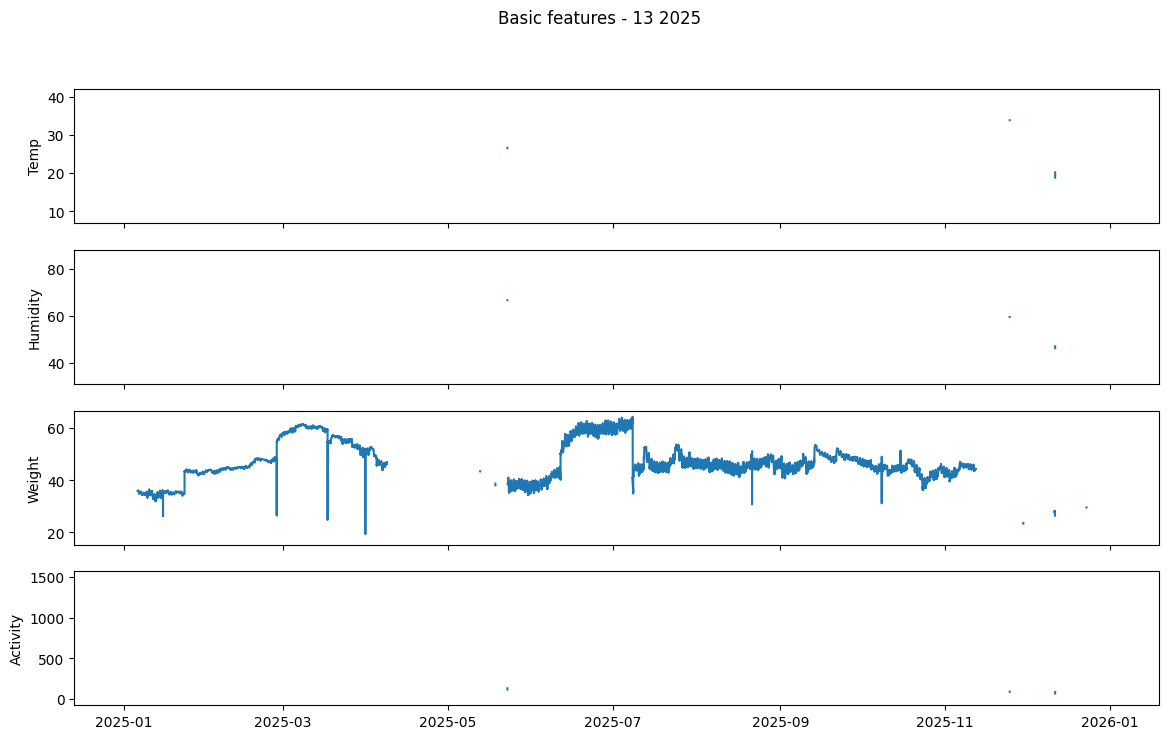

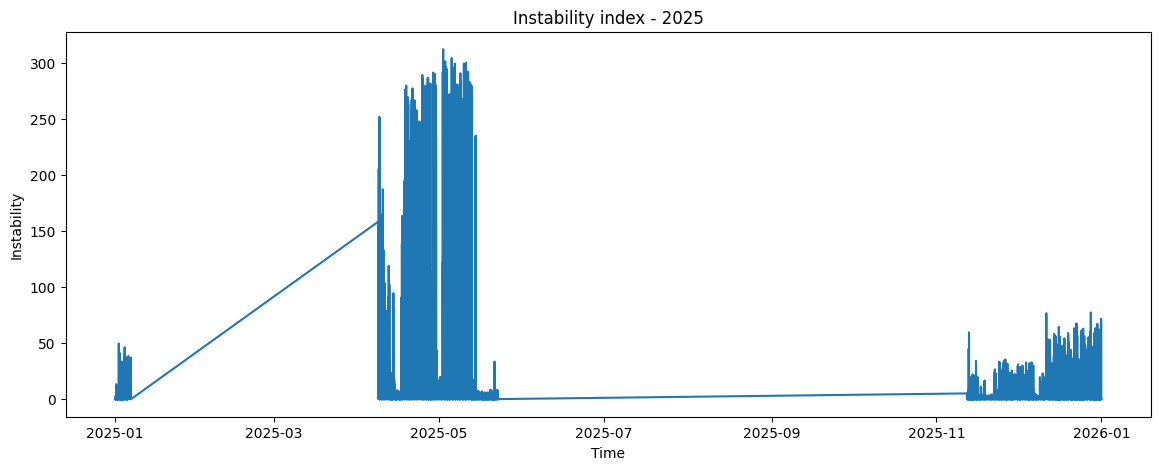

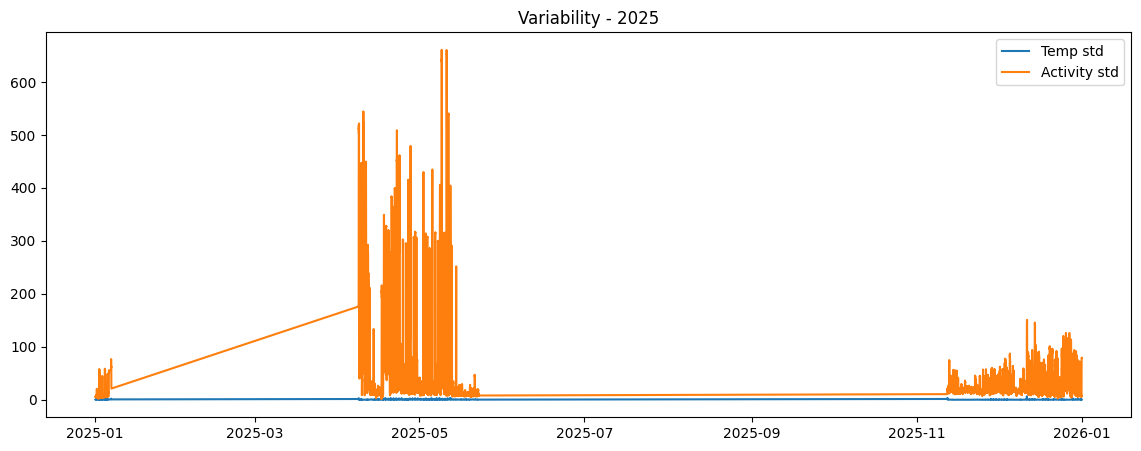

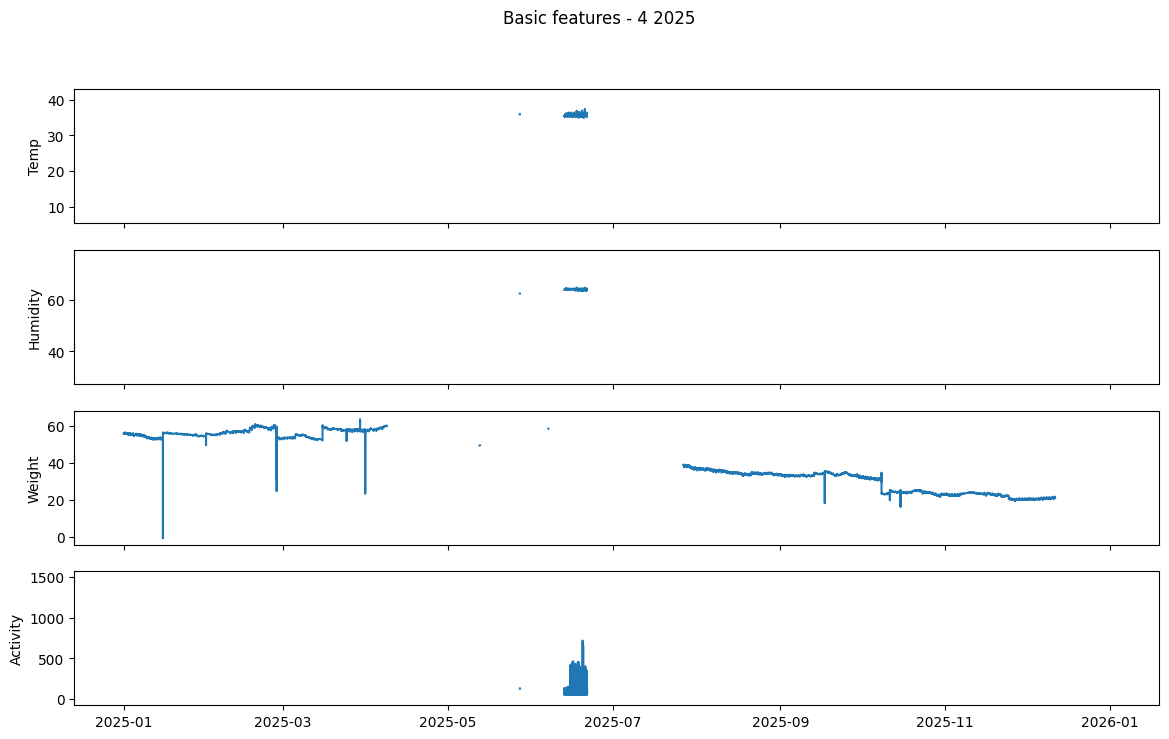

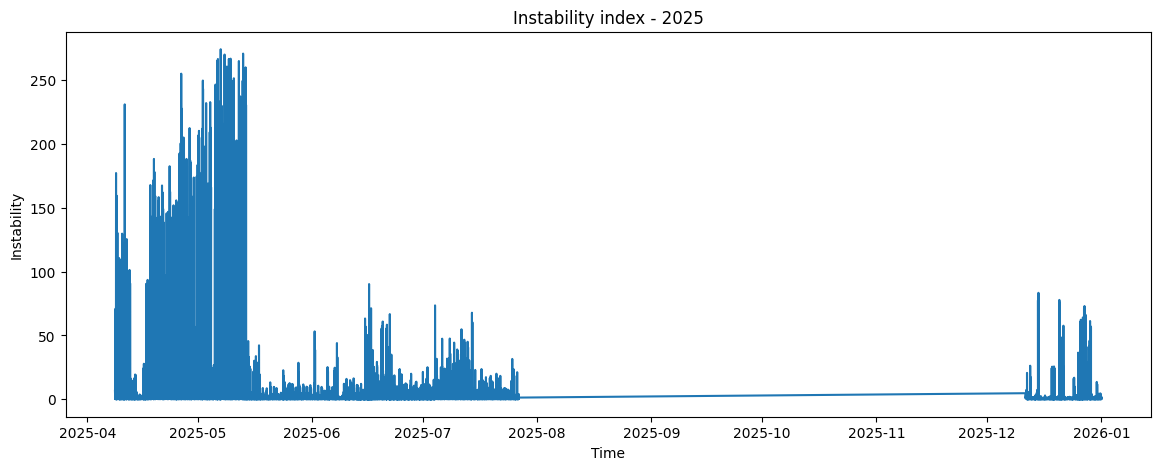

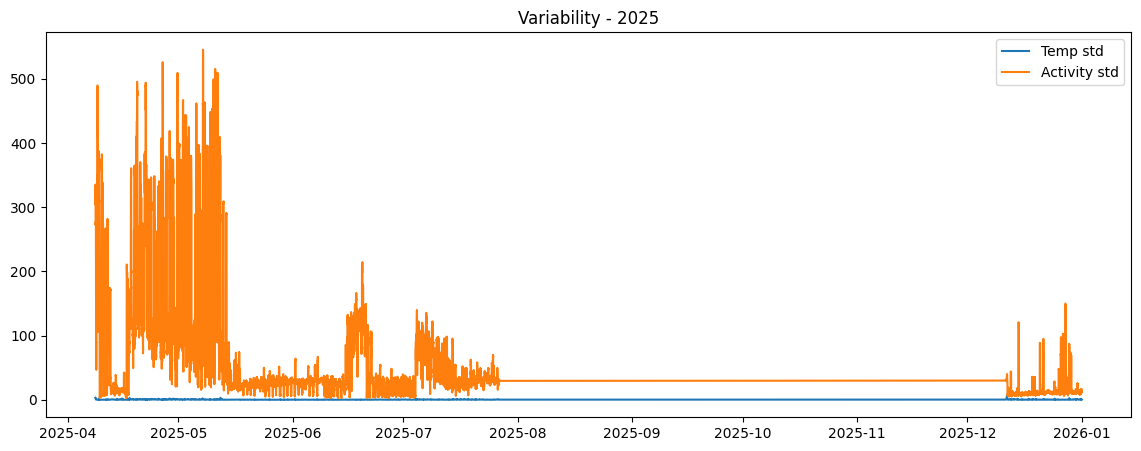

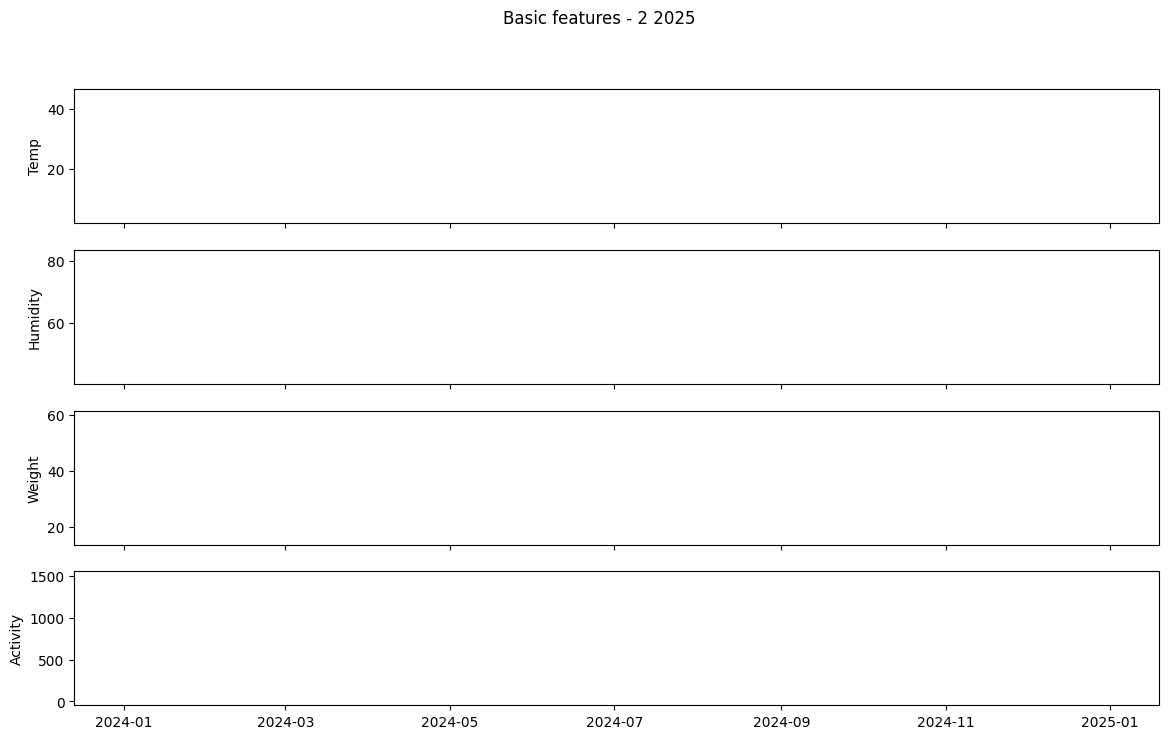

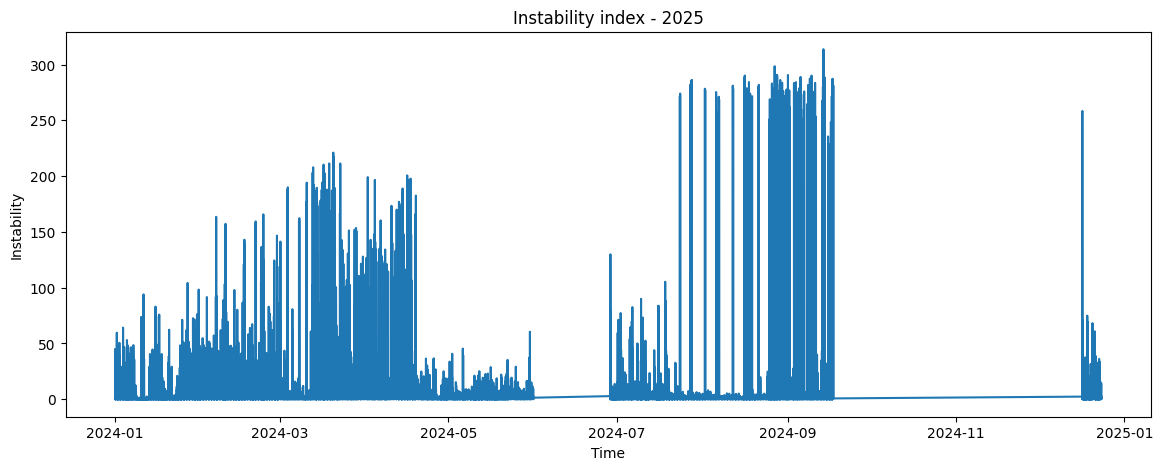

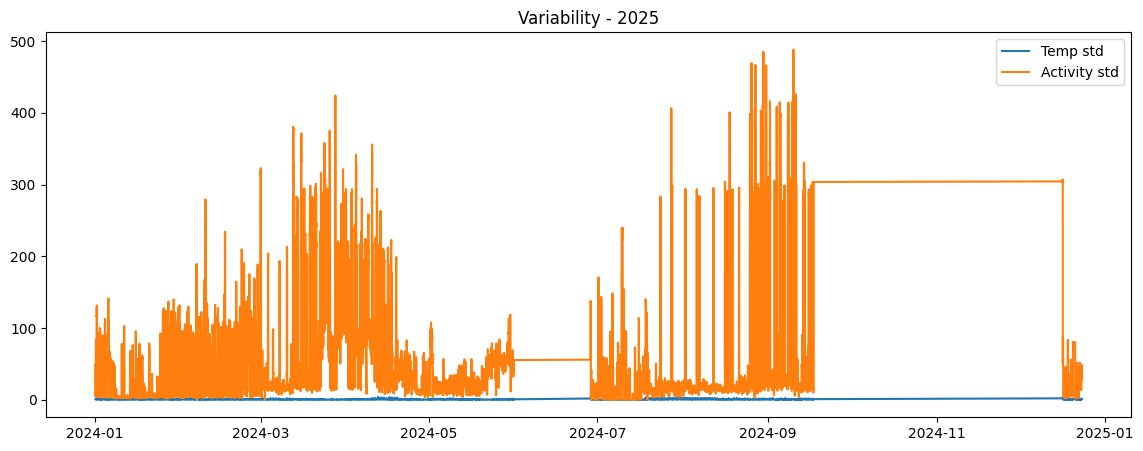

In [38]:
for df in [box13_2025, box4_2025, box2_2024]:
    plot_basic(df, f"Basic features - {df['Hive name'].iloc[0]} 2025")
    df = clean_weight(df)
    df = extract_heart(df)
    df = create_features(df)
    plot_instability(df, f"2025")
    plot_variability(df, f"2025")

In [41]:

box13_2025 = clean_weight(box13_2025)
box13_2025 = extract_heart(box13_2025)
box13_2025 = create_features(box13_2025)


In [42]:
swarm_events = {
    13: ["2025-04-16"],
    4: ["2025-04-23"],
    2: ["2024-05-24 13:26:57"]
}
def plot_with_events(df, swarm_times, title):

    plt.figure(figsize=(14,5))

    plt.plot(df['Time'], df['instability'], label='Instability')

    for t in swarm_times:
        plt.axvline(pd.to_datetime(t), color='red')

    plt.legend()
    plt.title(title)

    plt.show()

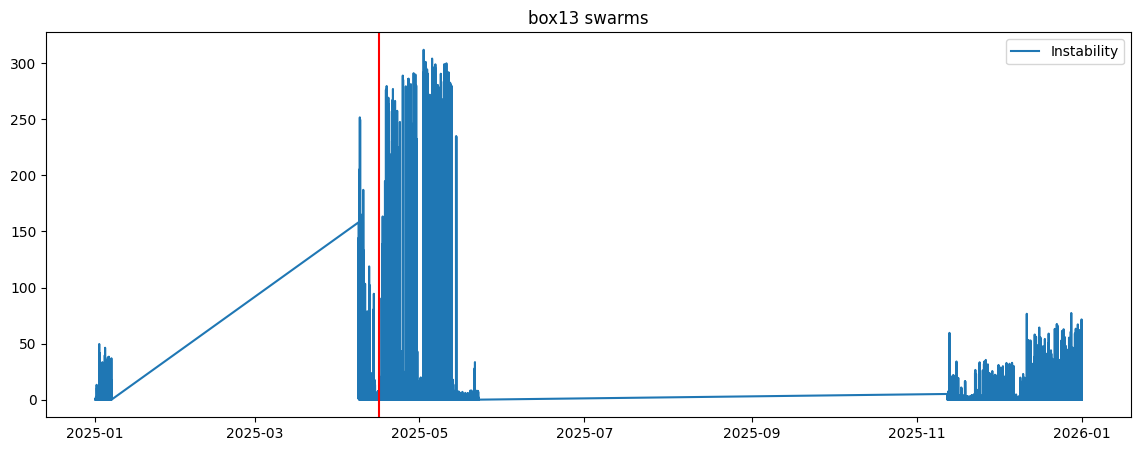

In [43]:
plot_with_events(box13_2025, swarm_events[13], "box13 swarms")